In [1]:
# bỏ tail model do data ít phải học phân phối nhiễu

# 💡 Gap lớn = overfit / shift / tail noisy
# 💡 Gap nhỏ nhưng val_loss tệ = underfit
# !pip install optuna
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Eval
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_pinball_loss

# CV
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.ensemble import GradientBoostingRegressor
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, CatBoostClassifier
# from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_pinball_loss,make_scorer
# from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Hyper tuning
from skopt import BayesSearchCV
from sklearn.model_selection import RandomizedSearchCV
import optuna

# Training
from sklearn.model_selection import KFold
# Gate
from sklearn.model_selection import StratifiedKFold

# Calibrate
from sklearn.linear_model import QuantileRegressor

print(sys.executable)
print(sys.version)

# Không có copy khi sao bản mới, b = a copy mỗi con trỏ, đường dẫn tới mảng đó

C:\Users\trieu\miniconda3\envs\PJ1_310\Scripts\python.exe
3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]


In [2]:
# Vùng flat
# improve_rate=(Lt−1-Lt)/Lt-1
# < 1% → bắt đầu nghi ngờ plateau

# < 0.5% → gần như flat

# < 0.1% → flat rõ ràng, tối ưu thêm không đáng

# | gap ratio | Ý nghĩa                     |
# | --------- | --------------------------- |
# | ≈ 0       | train ≈ val → fit ổn        |
# | 0.1 – 0.3 | overfit nhẹ, chấp nhận được |
# | 0.3 – 0.6 | overfit rõ ràng             |
# | > 1.0     | overfit nặng                |


In [3]:
def interval_score(y, low, high, alpha):
    width = high - low
    below = (low - y) * (y < low)
    above = (y - high) * (y > high)
    return np.mean(width + 2/alpha * below + 2/alpha * above)

In [4]:
def eval_quantile_model(model,alpha,len_train_sample,
                        X_train,y_train,
                        X_val, y_val,
                       lam=0.3):
    pred_train = np.expm1(model.predict(X_train))
    pred_val = np.expm1(model.predict(X_val))

    train_loss= mean_pinball_loss(y_train, pred_train, alpha = alpha)
    train_rel_loss = train_loss/np.mean(y_train) # do chia với y => rel
    train_cover = np.mean(y_train <= pred_train)

    val_loss = mean_pinball_loss(y_val, pred_val, alpha = alpha)
    val_rel_loss = val_loss/np.mean(y_train) # do chia với y => rel
    val_cover = np.mean(y_val <= pred_val)

    mae = np.mean(np.abs(y_val - pred_val))
    rmse = np.sqrt(np.mean((y_val - pred_val)**2))

    
    rel_gap = val_rel_loss - train_rel_loss #model với data mới
    
    gap_ratio = rel_gap / train_rel_loss
    overfit_score = rel_gap * np.sqrt(len_train_sample) #(len_train_sample ** 0.5)
    
    total_score = val_rel_loss + lam * max(rel_gap,0)
    
    print(pd.DataFrame({
    'quantile:': f"{alpha*100}",
    'train loss': [train_rel_loss],
    'val loss': [val_rel_loss],#⭐⭐⭐
    'train_cover:':[train_cover],
    'val_cover:':[val_cover],#⭐⭐⭐
    'rel_gap':[rel_gap],#⭐⭐⭐ gap tương đối là 1-50%, tuyệt đối:trừ thẳng giá trị thật loss 1-20%
    'gap_ratio':[gap_ratio],
    # 'overfit score':[overfit_score],
    'total_score':[total_score],#⭐⭐⭐
    'Mae':[mae],
    'rmse':[rmse]
    # Các metric khác đều là phụ
    }))
    

In [5]:
# # # # phạt overfit, không phạt underfit khi gap âm
# # # | λ nhỏ                | λ lớn              |
# # # | -------------------- | ------------------ |
# # # | Ít phạt overfit      | Phạt overfit mạnh  |
# # # | Chọn model loss thấp | Chọn model ổn định |
# # # | Dễ overfit           | Dễ underfit        |

# # | Mức độ           | λ khuyên dùng |
# # | ---------------- | ------------- |
# # | Nhẹ              | 0.05          |
# # | Vừa (chuẩn)      | **0.1 – 0.3** |
# # | Rất ghét overfit | 0.5 – 1.0     |
# # dùng mean 1 tập chia không sẽ so sánh hai metric ở hai thang đo khác nhau.

# 7. Khi nào mới chia theo mean của từng tập?

# Chỉ khi:

# bạn báo cáo metric độc lập

# không dùng để tính gap

# ví dụ: báo cáo MAE% trên test

In [6]:
def eval_quantile_test(model, alpha, X_test, y_test, y_train):
    pred_test = np.expm1(model.predict(X_test))

    test_loss = mean_pinball_loss(y_test, pred_test, alpha=alpha)
    test_rel_loss = test_loss / np.mean(y_train)
    test_cover = np.mean(y_test <= pred_test)

    mae = np.mean(np.abs(y_test - pred_test))
    rmse = np.sqrt(np.mean((y_test - pred_test)**2))

    print(pd.DataFrame({
        'quantile': [f"{alpha*100}"],
        'test_loss': [test_rel_loss],
        'test_cover': [test_cover],
        'mae': [mae],
        'rmse': [rmse]
    }))

In [7]:
# def eval_model_final(model, alpha, X_train, X_test, y_train, y_test,inverse_formula=None):
#     pred_train = model.predict(X_train)
#     pred_test = model.predict(X_test)
#     if inverse_formula is not None:
#         pred_train = inverse_formula(pred_train)
#         pred_test = inverse_formula(pred_test)
    
#     rel_loss_train = mean_pinball_loss(y_train, pred_train, alpha = alpha)/np.mean(y_train)
#     train_cover = np.mean(y_train <= pred_train)

#     rel_loss_test = mean_pinball_loss(y_test, pred_test, alpha = alpha)/np.mean(y_test) # do chia với y => rel
#     test_cover = np.mean(y_test <= pred_test)
#     mae = np.mean(np.abs(y_test - pred_test)) #mean absolute error
#     print(pd.DataFrame({
#     'quantile:': f"{alpha*100}",
#     'train loss': [rel_loss_train],
#     'train_cover:':[train_cover],
#     'test loss': [rel_loss_test],
#     'test_cover:':[test_cover],
#     'rel loss gap':[rel_loss_gap],
#     'MAE':[mea]
#     }))

In [8]:
# Tạo list bên ngoài để giữ lại giá trị trong vòng lặp
# return {
#     "oof": oof_pred,
#     "models": models,
#     "val_idx": val_indices
# }
def train_quantile_fold_model(X, y, alpha, params,early_stopping_rounds=100, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle = True, random_state= random_state)
    val_indices = []
    oof_pred = np.zeros(len(y))
    models = []
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            loss_function=f"Quantile:alpha={alpha}",
            random_seed=random_state + fold,
            verbose=False,
            **params
        )
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=early_stopping_rounds,
            use_best_model=True
        )
        
        pred_val = model.predict(X_val)
        oof_pred[val_idx] = pred_val
        models.append(model)
        val_indices.append(val_idx)

        # pinball loss cho fold
        err = y_val - pred_val
        pinball = np.mean(np.maximum(alpha*err, (alpha-1)*err))
        fold_scores.append(pinball)
        
        
    print(f"OOF pinball q{int(alpha*100)} = {np.mean(fold_scores):.5f}")
    return models,oof_pred

In [9]:
def train_gate_fold_model(X, tail_flag, params, n_splits=5, random_state=42):

    tail_flag = np.asarray(tail_flag)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof = np.zeros(len(X))
    models = []

    for train_idx, val_idx in kf.split(X, tail_flag):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = tail_flag[train_idx], tail_flag[val_idx]

        model = CatBoostClassifier(**params, verbose=0)

        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=100,
            use_best_model=True
        )

        oof[val_idx] = model.predict_proba(X_val)[:, 1]
        models.append(model)

    return models, oof

In [10]:
def objective_low(trial):
    alpha = trial.suggest_float("alpha", 0.08, 0.15)
    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("lr", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2", 1, 5000, log=True),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        "random_seed": 42,
        "loss_function": f"Quantile:alpha={alpha}",
        "verbose": 0
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    losses = []

    for train_idx, val_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)
        loss = mean_pinball_loss(y_val, pred, alpha=alpha)

        losses.append(loss)

    return np.mean(losses)

In [11]:
def objective_mid(trial):
    alpha = trial.suggest_float("alpha", 0.45, 0.55)
    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("lr", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2", 1, 5000, log=True),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        "random_seed": 42,
        "loss_function": f"Quantile:alpha={alpha}",
        "verbose": 0
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    losses = []

    for train_idx, val_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)
        loss = mean_pinball_loss(y_val, pred, alpha=alpha)

        losses.append(loss)

    return np.mean(losses)

In [12]:
def objective_high(trial):
    alpha = trial.suggest_float("alpha", 0.85, 0.95)

    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("lr", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2", 1, 5000, log=True),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        "random_seed": 42,
        "loss_function": f"Quantile:alpha={alpha}",
        "verbose": 0
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    losses = []

    for train_idx, val_idx in kf.split(X):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr)

        pred = model.predict(X_val)
        loss = mean_pinball_loss(y_val, pred, alpha=alpha)

        losses.append(loss)

    return np.mean(losses)

In [13]:
import optuna

def objective_gate(trial):

    params = {
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("lr", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2", 1, 10),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        "random_seed": 42,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
    }

    _, oof = train_gate_fold_model(X_train, tail_flag, params)

    return roc_auc_score(tail_flag, oof)

In [14]:
# def evaluation_fold_model(models,X,y, cv=5, lambda_risk= 0.05):
#     result={}
#     for name, model in models.items():
#         # item trả về key, value
#         scores = cross_val_score(model,X,y, cv=cv, scoring=pinball_scorer)/ np.mean(y)
#         # Chọn metric trước không lại phải quay lại
#         mean_score = scores.mean()
#         std_score = scores.std()
#         risk_adjusted = mean_score + lambda_risk * std_score
#         result[name] = {
#             'mean': mean_score,
#             'std': std_score,
#             'risk_adjusted': risk_adjusted
#         }
#         # Cách gọi value = Ghi đè key lên
#     return result

In [15]:
df_processed = pd.read_csv('../../data/processed/df_processed.csv', index_col=0) #index_col=0 bỏ index cũ (cột unnamed:0)
df_processed

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,...,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_level_poor,income_level_mid,income_level_upper-mid,income_level_rich,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,2.555556,...,False,False,False,True,False,False,False,False,True,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,2.109842,...,False,False,False,True,False,False,False,True,False,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,2.802260,...,False,False,False,True,False,False,False,False,True,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,2.547945,...,False,False,False,True,False,False,False,False,True,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,2.181467,...,False,False,False,True,False,False,False,True,False,342200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,2.560606,...,False,True,False,False,False,False,True,False,False,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,3.122807,...,False,True,False,False,False,False,False,True,False,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,2.325635,...,False,True,False,False,False,True,False,False,False,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,2.123209,...,False,True,False,False,False,False,True,False,False,84700.0


In [16]:
y= df_processed.loc[:,'median_house_value']
y_mask=np.percentile(y,90)
# is_q90= y>=y_mask
# y_q90= y[is_q90]
# y_q90.reset_index(inplace=True, drop=True)
# y_q90 (2066)-> #  small data regime

In [17]:
num_cols= df_processed.drop(df_processed.columns[[-4,-3]], axis=1)
X= df_processed.drop('median_house_value', axis=1)
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,income_per_person,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_level_poor,income_level_mid,income_level_upper-mid,income_level_rich
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,2.555556,0.025855,False,False,False,True,False,False,False,False,True
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,2.109842,0.003457,False,False,False,True,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,2.802260,0.014632,False,False,False,True,False,False,False,False,True
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,2.547945,0.010113,False,False,False,True,False,False,False,False,True
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,2.181467,0.006807,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,2.560606,0.001847,False,True,False,False,False,False,True,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,3.122807,0.007182,False,True,False,False,False,False,False,True,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,2.325635,0.001688,False,True,False,False,False,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,2.123209,0.002520,False,True,False,False,False,False,True,False,False


In [18]:
# Sửa lỗi LightGBM
X.columns = X.columns.str.replace(r"[\[\]<>?]", "_", regex=True)
X.columns = [c.replace(" ", "_") for c in X.columns]
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,income_per_person,ocean_proximity__1H_OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR_BAY,ocean_proximity_NEAR_OCEAN,income_level_poor,income_level_mid,income_level_upper-mid,income_level_rich
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,2.555556,0.025855,False,False,False,True,False,False,False,False,True
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,2.109842,0.003457,False,False,False,True,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,2.802260,0.014632,False,False,False,True,False,False,False,False,True
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,2.547945,0.010113,False,False,False,True,False,False,False,False,True
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,2.181467,0.006807,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,5.045455,2.560606,0.001847,False,True,False,False,False,False,True,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,6.114035,3.122807,0.007182,False,True,False,False,False,False,False,True,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,5.205543,2.325635,0.001688,False,True,False,False,False,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,5.329513,2.123209,0.002520,False,True,False,False,False,False,True,False,False


In [19]:
# Split
# Mỗi cặp x, y gắn liền với 1 tune trong pipeline, tránh pipeline leak, mỗi 1 phiên bản của 1 val dùng mấy lần
# cách 1 chia 4 val
# 2 evaluate duy nhất lần cuối để tuning cả 1 tập, 
# Để tránh chia val làm 4 => eval ở cuối, tất cả pipeline đến gate chỉ được evaluate khi nào xong
# \ Tạo thêm sample từ model đã train (khả năn overfit), lúc đó các hàm val của model trước vẫn không được liên quan đến sau
# \ Dùng fold cho cả 3 => kết quả fold model không nhìn thấy kết quả, => y_train sử dụng để evaluate lại model được
# fold:q10 q50 q90 eval: y_train
# gate 90: eval val1
# tail val 2
# Leak chỉ không xảy ra với y trên tập mà nó chưa từng biết, evaluate(view và tuning) đi kèm với tuning leak trong cả pipeline và model độc lập cần để ý

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.1, random_state = 42)
X_train.reset_index(inplace= True, drop=True)
y_train.reset_index(inplace= True, drop=True)
X_test.reset_index(inplace= True, drop=True)
y_test.reset_index(inplace= True, drop=True)
# tránh pipeline leak

In [21]:
y_train_log = np.log1p(y_train)
y_test_log= np.log1p(y_test)

In [22]:
y_train_log

0        11.960179
1        12.964073
2        12.639804
3        12.385059
4        11.602775
           ...    
18571    12.342355
18572    11.490690
18573    12.310888
18574    12.554971
18575    12.691584
Name: median_house_value, Length: 18576, dtype: float64

In [23]:

alpha = 0.1

# Model base - mô hình dò, kèm theo tham số cố định

cat = CatBoostRegressor(
    loss_function=f'Quantile:alpha={alpha}',
    verbose=0,
    random_state=42,
    allow_writing_files=False
)
# Tạo khoảng param tìm tron
# Không nên để iterations quá rộng
param_space = {
    'depth': (3, 8),
    'learning_rate': (0.01, 0.15, 'log-uniform'),
    'l2_leaf_reg': (1, 10),
    'iterations': (800, 2000),  # giảm range
    'subsample': (0.6, 1.0),
    'random_strength': (0.1, 10.0, 'log-uniform')
}

# Pinball scorer (BayesSearch sẽ maximize -> phải để negative)
pinball_scorer = make_scorer(
    mean_pinball_loss,
    alpha=alpha,
    greater_is_better=False
)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator=cat,
    search_spaces=param_space,
    n_iter=40,  
    cv=cv,
    scoring=pinball_scorer,
    random_state=42,
    n_jobs=-1,
    refit=True
)
# Tính => fold val, tính điểm CV(tối ưu loss), tuning lại

# bayes_search.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_train, y_train)],   
#     early_stopping_rounds=100
# ) #⭐⭐⭐⭐⭐⭐


# best_params = bayes_search.best_params_

# print(
#     "q10 = CatBoostRegressor(\n" +
#     ",\n".join([f"    {k}={repr(v)}" for k, v in best_params.items()]) +
# # lấy từng (k, v)
# # → tạo string theo format trên "    depth=6"
# # → tạo string "    learning_rate=0.03"
# # → gom vào list
#     "\n)"
# )

# q10 = CatBoostRegressor(
#     depth=4,
#     iterations=1393,
#     l2_leaf_reg=9,
#     learning_rate=0.04354649621019324,
#     random_strength=7.179140199871386,
#     subsample=0.9097353598866685
# )

# best_params = {
#     "depth": 6,
#     "learning_rate": 0.03
# }
# best_params.items() = 
# ("depth", 6)
# ("learning_rate", 0.03)⭐⭐


In [24]:
# study_low = optuna.create_study(direction="minimize")
# study_low.optimize(objective_low, n_trials=100)
# print("Total trials low:", len(study_low.trials))
# print("Best trial index low:", study_low.best_trial.number)
# print("Best score low:", study_low.best_value)
# print("Best params low:", study_low.best_params)
# # {'alpha': 0.08001160911494612, 'depth': 5, 'lr': 0.032198326647507526, 'l2': 1107.3286213039844, 'iterations': 1753, 'subsample': 0.9142797526921373, 'rsm': 0.8132133205621078}

# Bỏ
# # {'alpha': 0.08019174941464524,
# #  'depth': 5,
# #  'lr': 0.02535284668171561,
# #  'l2': 1.039294856901308,
# #  'iterations': 1570,
# #  'subsample': 0.9029682368402795,
# #  'rsm': 0.8093882368077202}


In [25]:
# study_mid = optuna.create_study(direction="minimize")
# study_mid.optimize(objective_mid, n_trials=100)
# print("Total trials mid:", len(study_mid.trials))
# print("Best trial index mid:", study_mid.best_trial.number)
# print("Best score mid:", study_mid.best_value)
# print("Best params mid:", study_mid.best_params)
    
# # print(study_mid.best_params)
# # {'alpha': 0.4500818598268272, 'depth': 7, 'lr': 0.07214912748831369, 'l2': 337.0236575836845, 'iterations': 1793, 'subsample': 0.9558553037559883, 'rsm': 0.8618310770176018}
# # {'alpha': 0.46590369721962954,
# #  'depth': 6,
# #  'lr': 0.06627141200410817,
# #  'l2': 40.22901766231428,
# #  'iterations': 1792,
# #  'subsample': 0.9392125649714503,
# #  'rsm': 0.9489746826239729}


In [26]:
# lower = CatBoostRegressor(
#     depth=4,
#     iterations=500,
#     l2_leaf_reg=9, # phạt
#     learning_rate=0.038275576007207185,
#     loss_function="Quantile:alpha=0.1",
#     random_strength=0.16620612512184482,
#     subsample=0.8344892090454218,
#     verbose=False
#     )


low_model = CatBoostRegressor(
    depth= 5,
    learning_rate =  0.032198326647507526,
    l2_leaf_reg =  1107.3286213039844,
    iterations = 1753,
    subsample = 0.9142797526921373,
    rsm = 0.8132133205621078,
    loss_function = 'Quantile:alpha=0.08001160911494612',
    verbose=False,
)



# Vùng flat
low_model.fit(X_train,y_train_log)

In [27]:
low_pred_train = np.expm1(low_model.predict(X_train))
rel_loss_low = mean_pinball_loss(y_train, low_pred_train, alpha=0.08001160911494612)/np.mean(y_train)*100
coverage_low = np.mean(y_train <= low_pred_train)*100

print('Train Loss :',rel_loss_low,'%')
print('Train Cover :',coverage_low,'%')

Train Loss : 2.1429319304524173 %
Train Cover : 7.924203273040482 %


In [28]:
# Chốt low với hàm test
low_pred_test = np.expm1(low_model.predict(X_test))
rel_loss_low_pred_test = mean_pinball_loss(y_test, low_pred_test, alpha=0.08001160911494612)/np.mean(y_train)*100
coverage_low_pred_test = np.mean(y_test <= low_pred_test)*100
print('Test Loss :',rel_loss_low_pred_test,'%')
print('Test Cover :',coverage_low_pred_test,'%')

Test Loss : 2.419971456346273 %
Test Cover : 9.738372093023257 %


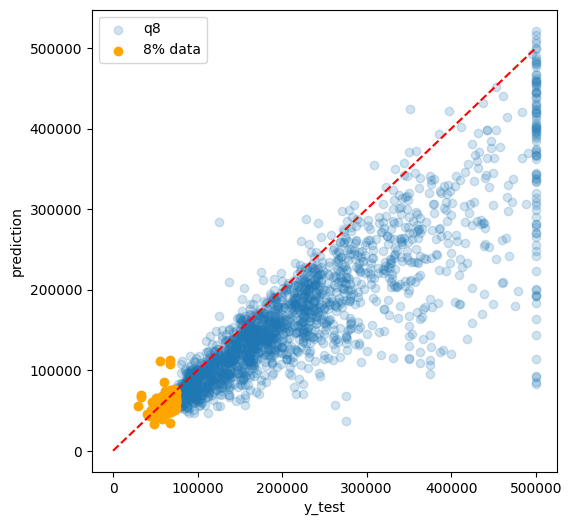

In [29]:
mask_top10_bottom_test= y_test<=np.percentile(y_train, 8)
plt.figure(figsize=(6,6))
plt.scatter(x=y_test,y=low_pred_test,alpha=0.2,label='q8')
plt.scatter(x=y_test[mask_top10_bottom_test],y=low_pred_test[mask_top10_bottom_test],label='8% data',color="orange")
plt.plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')  # đường chuẩn đúng

# plt.xlim(min_y, max_y)
# plt.ylim(min_y, max_y)

plt.xlabel("y_test")
plt.ylabel("prediction")
plt.legend()

In [30]:
mid_bound_params = {'alpha': 0.4500818598268272, 'depth': 7, 'lr': 0.07214912748831369, 'l2': 337.0236575836845, 'iterations': 1793, 'subsample': 0.9558553037559883, 'rsm': 0.8618310770176018}
mid_param = (
    "CatBoostRegressor(\n"
    + ",\n".join(f"    {k}={repr(v)}" for k, v in mid_bound_params.items())
    + "\n)"
)

print(mid_param)

CatBoostRegressor(
    alpha=0.4500818598268272,
    depth=7,
    lr=0.07214912748831369,
    l2=337.0236575836845,
    iterations=1793,
    subsample=0.9558553037559883,
    rsm=0.8618310770176018
)


In [31]:
mid_model=CatBoostRegressor(
    depth=7,
    learning_rate=0.07214912748831369,
    l2_leaf_reg=337.0236575836845,
    iterations=1793,
    subsample=0.9558553037559883,
    rsm=0.8618310770176018,
    loss_function = 'Quantile:alpha=0.4500818598268272',
    verbose=False,
)
# Vùng flat
mid_model.fit(X_train,y_train_log)

In [32]:
mid_pred_train = np.expm1(mid_model.predict(X_train))
rel_loss_mid = mean_pinball_loss(y_train, mid_pred_train, alpha=0.4500818598268272)/np.mean(y_train)*100
coverage_mid = np.mean(y_train <= mid_pred_train)*100

print('Train Loss :',rel_loss_mid,'%')
print('Train Cover :',coverage_mid,'%')

Train Loss : 4.653812619800124 %
Train Cover : 44.97739018087855 %


In [33]:
# Chốt mid với hàm test
mid_pred_test = np.expm1(mid_model.predict(X_test))
rel_loss_mid_pred_test = mean_pinball_loss(y_test, mid_pred_test, alpha=0.08001160911494612)/np.mean(y_train)*100
coverage_mid_pred_test = np.mean(y_test <= mid_pred_test)*100
print('Test Loss :',rel_loss_mid_pred_test,'%')
print('Test Cover :',coverage_mid_pred_test,'%')

Test Loss : 4.818436825832227 %
Test Cover : 45.78488372093023 %


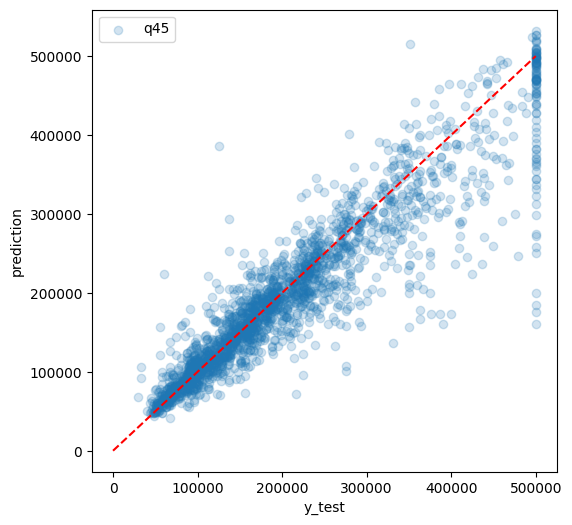

In [34]:
plt.figure(figsize=(6,6))
plt.scatter(x=y_test,y=mid_pred_test,alpha=0.2,label='q45')
plt.plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')  # đường chuẩn đúng

# plt.xlim(min_y, max_y)
# plt.ylim(min_y, max_y)

plt.xlabel("y_test")
plt.ylabel("prediction")
plt.legend()

In [35]:
# study_high = optuna.create_study(direction="minimize")
# study_high.optimize(objective_high, n_trials=100)
# print("Total trials high:", len(study_high.trials))
# print("Best trial index high:", study_high.best_trial.number)
# print("Best score high:", study_high.best_value)
# print("Best params high:", study_high.best_params)
# {'alpha': 0.9495274346479041, 'depth': 4, 'lr': 0.03178227344875425, 'l2': 4.209054319788341, 'iterations': 1951, 'subsample': 0.526143289163985, 'rsm': 0.9456531039389332}


In [36]:
high_params = {'alpha': 0.9495274346479041, 'depth': 4, 'lr': 0.03178227344875425, 'l2': 4.209054319788341, 'iterations': 1951, 'subsample': 0.526143289163985, 'rsm': 0.9456531039389332}


high_params = (
    "CatBoostRegressor(\n"
    + ",\n".join(f"    {k}={repr(v)}" for k, v in high_params.items())
    + "\n)"
)

print(high_params)

CatBoostRegressor(
    alpha=0.9495274346479041,
    depth=4,
    lr=0.03178227344875425,
    l2=4.209054319788341,
    iterations=1951,
    subsample=0.526143289163985,
    rsm=0.9456531039389332
)


In [37]:
high_model = CatBoostRegressor(
    depth=4,
    learning_rate=0.03178227344875425,
    l2_leaf_reg=4.209054319788341,
    iterations=1951,
    subsample=0.526143289163985,
    rsm=0.9456531039389332,
    loss_function = 'Quantile:alpha=0.9495274346479041',
    verbose = False,
)
high_model.fit(X_train,y_train_log)

In [38]:
high_pred_train = np.expm1(high_model.predict(X_train))
rel_loss_high = mean_pinball_loss(y_train, high_pred_train, alpha=0.4500818598268272)/np.mean(y_train)*100
coverage_high = np.mean(y_train <= high_pred_train)*100

print('Train Loss :',rel_loss_high,'%')
print('Train Cover :',coverage_high,'%')

Train Loss : 19.260655250848373 %
Train Cover : 95.00968992248062 %


In [39]:
# Chốt high với hàm test
high_pred_test = np.expm1(high_model.predict(X_test))
rel_loss_high_pred_test = mean_pinball_loss(y_test, high_pred_test, alpha=0.08001160911494612)/np.mean(y_train)*100
coverage_high_pred_test = np.mean(y_test <= high_pred_test)*100
print('Test Loss :',rel_loss_high_pred_test,'%')
print('Test Cover :',coverage_high_pred_test,'%')

Test Loss : 32.30722729028485 %
Test Cover : 93.21705426356588 %


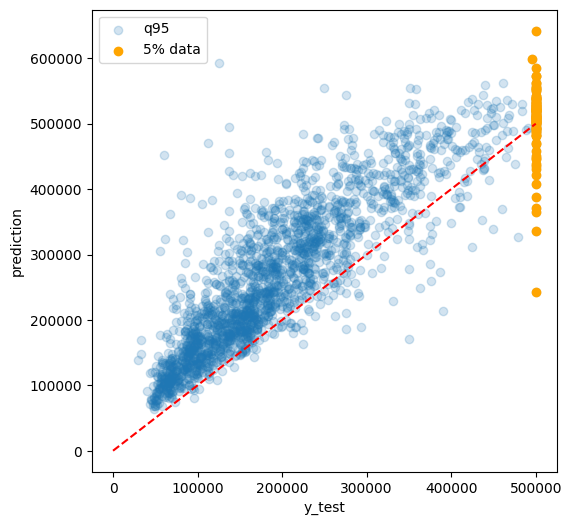

In [40]:
mask_top10_above_test= y_test>=np.percentile(y_train, 95)
plt.figure(figsize=(6,6))
plt.scatter(x=y_test,y=high_pred_test,alpha=0.2,label='q95')
plt.scatter(x=y_test[mask_top10_above_test],y=high_pred_test[mask_top10_above_test],label='5% data',color="orange")
plt.plot([0, np.max(y_test)], [0, np.max(y_test)], 'r--')  # đường chuẩn đúng

# plt.xlim(min_y, max_y)
# plt.ylim(min_y, max_y)

plt.xlabel("y_test")
plt.ylabel("prediction")
plt.legend()

In [41]:
# Coverage trên test
coverlow_high_test = np.mean((y_test >= low_pred_test) & (y_test <= high_pred_test))
# Interval width (train & test)
width_test_mean= np.mean(high_pred_test - low_pred_test)
print("Test coverage 8-94:", coverlow_high_test, "Width mean:", width_test_mean)
score = width_test_mean/coverlow_high_test 
print("score:",score)

Test coverage 8-94: 0.8347868217054264 Width mean: 117512.7960905279
score: 140769.8265414101


In [42]:
interval_score = interval_score(y_test, low_pred_test, high_pred_test, alpha=0.14) # 1-(94-8)

In [44]:
interval_score

np.float64(169829.87311440156)